In [1]:
import os
from PIL import Image
import warnings

warnings.filterwarnings('ignore')

# Ný nhớ click chuột phải vào thư mục Images bên cột phải Kaggle -> Copy file path rồi dán đè vào đây nhé
source_dir = '/kaggle/input/datasets/quandang/vietnamese-foods/Images' 

purified_dir = '/kaggle/working/Purified_Images'
print("Bắt đầu chiến dịch đập đi xây lại toàn bộ hình ảnh...")

bad_files = 0
good_files = 0

# ĐÃ SỬA CHỖ NÀY: Viết hoa y hệt cấu trúc thư mục của Dataset
for split in ['Train', 'Validate', 'Test']: 
    orig_split = os.path.join(source_dir, split)
    if not os.path.exists(orig_split): 
        print(f"⚠️ Không tìm thấy thư mục: {orig_split} - Ný check lại source_dir nhé!")
        continue
        
    for class_name in os.listdir(orig_split):
        orig_class = os.path.join(orig_split, class_name)
        purified_class = os.path.join(purified_dir, split, class_name)
        
        if not os.path.isdir(orig_class): 
            continue
            
        os.makedirs(purified_class, exist_ok=True)
        
        for filename in os.listdir(orig_class):
            orig_file = os.path.join(orig_class, filename)
            purified_file = os.path.join(purified_class, filename)
            
            if os.path.exists(purified_file):
                continue
                
            try:
                with Image.open(orig_file) as img:
                    rgb_im = img.convert('RGB')
                    rgb_im.save(purified_file, 'JPEG')
                    good_files += 1
            except Exception as e:
                bad_files += 1
                pass 

print("-" * 30)
print(f"=> Hoàn tất! Đã tái tạo thành công {good_files} ảnh siêu sạch.")
print(f"=> Đã loại bỏ hoàn toàn {bad_files} ảnh không thể cứu chữa.")

Bắt đầu chiến dịch đập đi xây lại toàn bộ hình ảnh...
------------------------------
=> Hoàn tất! Đã tái tạo thành công 25136 ảnh siêu sạch.
=> Đã loại bỏ hoàn toàn 0 ảnh không thể cứu chữa.


2026-03-03 07:34:12.715068: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772523253.135028      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772523253.247041      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772523254.280332      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772523254.280362      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772523254.280364      55 computation_placer.cc:177] computation placer alr

Đang quét thư mục để tải dữ liệu...
Found 17581 files belonging to 30 classes.


I0000 00:00:1772523293.676588      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772523293.682488      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



=> Các món ăn đã tìm thấy: ['Banh beo', 'Banh bot loc', 'Banh can', 'Banh canh', 'Banh chung', 'Banh cuon', 'Banh duc', 'Banh gio', 'Banh khot', 'Banh mi', 'Banh pia', 'Banh tet', 'Banh trang nuong', 'Banh xeo', 'Bun bo Hue', 'Bun dau mam tom', 'Bun mam', 'Bun rieu', 'Bun thit nuong', 'Ca kho to', 'Canh chua', 'Cao lau', 'Chao long', 'Com tam', 'Goi cuon', 'Hu tieu', 'Mi quang', 'Nem chua', 'Pho', 'Xoi xeo']
=> Tổng số nhãn (classes): 30


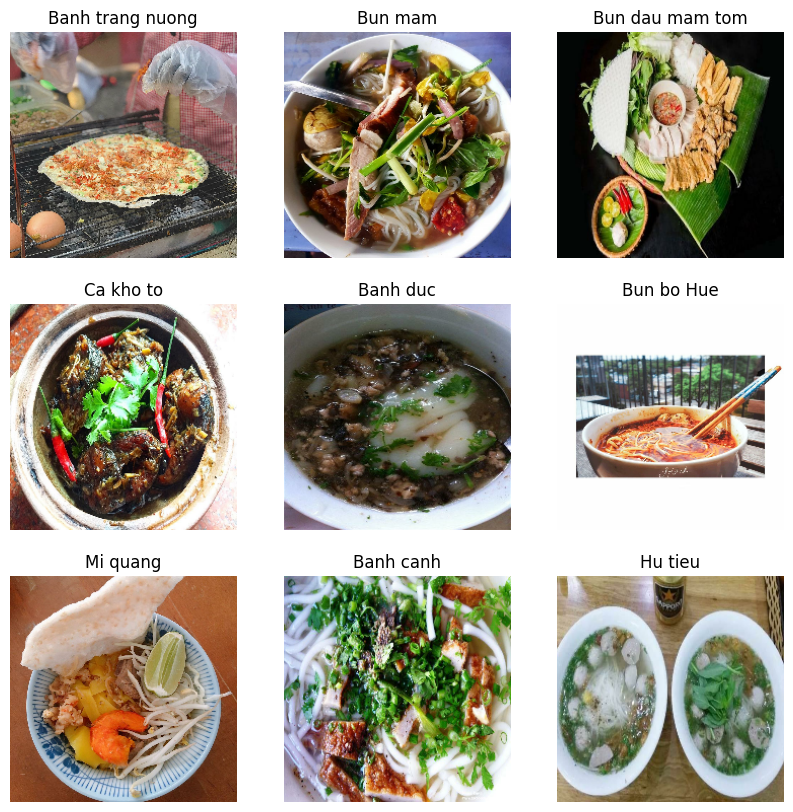

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# 1. Trỏ đường dẫn vào đúng thư mục train (dựa trên cấu trúc màn hình Kaggle của bạn)
base_dir = '/kaggle/working/Purified_Images'
train_dir = os.path.join(base_dir, 'Train')

# 2. Cài đặt thông số
BATCH_SIZE = 32        # Gom 32 ảnh thành 1 cụm (batch) để xử lý cùng lúc
IMG_SIZE = (224, 224)  # Kích thước chuẩn để đưa vào mạng CNN

# 3. Dùng hàm của Keras để tự động gom ảnh và gán nhãn
print("Đang quét thư mục để tải dữ liệu...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# Lấy ra danh sách tên các món ăn
class_names = train_dataset.class_names
print("\n=> Các món ăn đã tìm thấy:", class_names)
print("=> Tổng số nhãn (classes):", len(class_names))


# --- IN THỬ 9 ẢNH TỪ TẬP TRAIN ĐỂ NGHIỆM THU ---

plt.figure(figsize=(10, 10))

# Hàm take(1) bốc đúng 1 batch (32 ảnh) từ tập TRAIN ra xem
for images, labels in train_dataset.take(1): 
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        
        # Ép kiểu ma trận số thực về số nguyên (0-255) để vẽ lên màu chuẩn
        plt.imshow(images[i].numpy().astype("uint8"))
        
        # Gắn tên món ăn tương ứng lên đầu mỗi ảnh
        plt.title(class_names[labels[i]])
        plt.axis("off")
        
plt.show()

Đang quét thư mục để tải dữ liệu...
Found 2515 files belonging to 30 classes.

=> Các món ăn đã tìm thấy: ['Banh beo', 'Banh bot loc', 'Banh can', 'Banh canh', 'Banh chung', 'Banh cuon', 'Banh duc', 'Banh gio', 'Banh khot', 'Banh mi', 'Banh pia', 'Banh tet', 'Banh trang nuong', 'Banh xeo', 'Bun bo Hue', 'Bun dau mam tom', 'Bun mam', 'Bun rieu', 'Bun thit nuong', 'Ca kho to', 'Canh chua', 'Cao lau', 'Chao long', 'Com tam', 'Goi cuon', 'Hu tieu', 'Mi quang', 'Nem chua', 'Pho', 'Xoi xeo']
=> Tổng số nhãn (classes): 30


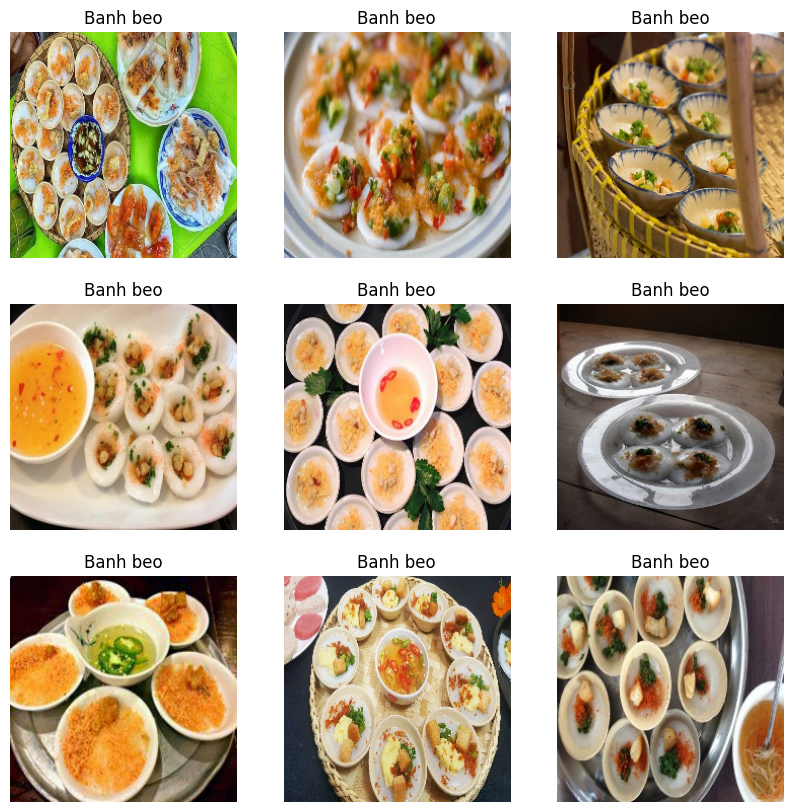

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# 1. Trỏ đường dẫn vào đúng thư mục train (dựa trên cấu trúc màn hình Kaggle của bạn)
base_dir = '/kaggle/working/Purified_Images'
val_dir = os.path.join(base_dir, 'Validate')

# 2. Cài đặt thông số
BATCH_SIZE = 32        # Gom 32 ảnh thành 1 cụm (batch) để xử lý cùng lúc
IMG_SIZE = (224, 224)  # Kích thước chuẩn để đưa vào mạng CNN

# 3. Dùng hàm của Keras để tự động gom ảnh và gán nhãn
print("Đang quét thư mục để tải dữ liệu...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

# Lấy ra danh sách tên các món ăn
class_names = val_dataset.class_names
print("\n=> Các món ăn đã tìm thấy:", class_names)
print("=> Tổng số nhãn (classes):", len(class_names))


# --- IN THỬ 9 ẢNH TỪ TẬP TRAIN ĐỂ NGHIỆM THU ---

plt.figure(figsize=(10, 10))

# Hàm take(1) bốc đúng 1 batch (32 ảnh) từ tập TRAIN ra xem
for images, labels in val_dataset.take(1): 
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        
        # Ép kiểu ma trận số thực về số nguyên (0-255) để vẽ lên màu chuẩn
        plt.imshow(images[i].numpy().astype("uint8"))
        
        # Gắn tên món ăn tương ứng lên đầu mỗi ảnh
        plt.title(class_names[labels[i]])
        plt.axis("off")
        
plt.show()

In [4]:
# 2. Tối ưu hóa luồng dữ liệu (Pipeline Performance)
# Bình thường: CPU đọc 1 batch ảnh -> đưa cho GPU học -> GPU học xong -> CPU mới lọ mọ đi đọc batch tiếp theo (rất chậm).
# Prefetch: CPU sẽ tự động chuẩn bị sẵn batch số 2, số 3 trong RAM trong lúc GPU đang học batch 1.
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
validation_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# --- BƯỚC 3: XÂY DỰNG KIẾN TRÚC MÔ HÌNH (Não bộ AI) ---

# 1. Tạo lớp Data Augmentation (Tăng cường dữ liệu)
# Ép máy tính học các góc độ khó hơn: lật ngang, xoay nghiêng ảnh.
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
])

# 2. Tải mô hình nền MobileNetV2 (Transfer Learning)
IMG_SHAPE = IMG_SIZE + (3,) # Kích thước 224x224 và 3 kênh màu RGB
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

print("Đang tải bộ não MobileNetV2 từ Google...")
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False, # QUAN TRỌNG NHẤT: Bỏ lớp phân loại cũ (nhận diện chó mèo/đồ vật)
    weights='imagenet' # Lấy lại kiến thức trích xuất đặc trưng từ hàng triệu bức ảnh
)

# 3. Đóng băng (Freeze) phần não bộ này lại
# Giai đoạn đầu, ta không cho máy cập nhật trọng số (weights) của phần này để tránh phá hỏng kiến thức cũ
base_model.trainable = False

# 4. Lắp ráp luồng đi của dữ liệu
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = data_augmentation(inputs)        # Bước A: Làm méo/lật ảnh
x = preprocess_input(x)              # Bước B: Chuẩn hóa pixel (đưa về chuẩn của MobileNet)
x = base_model(x, training=False)    # Bước C: Đưa qua não bộ (training=False để giữ đóng băng)

# 5. Gắn "Cái đầu" mới để nhận diện món ăn Việt Nam 
x = tf.keras.layers.GlobalAveragePooling2D()(x) # Ép phẳng ma trận đặc trưng thành vector 1 chiều
x = tf.keras.layers.Dropout(0.2)(x)             # Tắt ngẫu nhiên 20% nơ-ron để chống học vẹt (Overfitting)

# Lớp cuối cùng (Output layer): Số lượng nơ-ron ĐÚNG BẰNG số lượng món ăn
NUM_CLASSES = len(class_names)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

# Đóng gói toàn bộ thành 1 Model hoàn chỉnh
model = tf.keras.Model(inputs, outputs)

print("\n=> Lắp ráp thành công! Cấu trúc mô hình của bạn:")
model.summary()

Đang tải bộ não MobileNetV2 từ Google...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

=> Lắp ráp thành công! Cấu trúc mô hình của bạn:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │        38,430 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,296,414 (8.76 MB)

 Trainable params: 38,430 (150.12 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
# --- BƯỚC 4: BIÊN DỊCH VÀ HUẤN LUYỆN MÔ HÌNH (COMPILE & TRAIN) ---
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # <--- Thêm thư viện

base_learning_rate = 0.0001

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate), 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(), 
    metrics=['accuracy'] 
)

# --- THÊM CALLBACKS ---
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model_base.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

EPOCHS = 15 # Tăng lên 15 vì đã có Early Stopping bảo vệ

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, model_checkpoint] # <--- Gọi callbacks
)

# (Phần code vẽ biểu đồ bên dưới của bạn giữ nguyên)

Epoch 1/15


I0000 00:00:1772523305.327322     134 cuda_dnn.cc:529] Loaded cuDNN version 91002


550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.1102 - loss: 3.3384
Epoch 1: val_accuracy improved from -inf to 0.34871, saving model to best_model_base.keras
550/550 ━━━━━━━━━━━━━━━━━━━━ 55s 85ms/step - accuracy: 0.1103 - loss: 3.3377 - val_accuracy: 0.3487 - val_loss: 2.3322
Epoch 2/15
549/550 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3560 - loss: 2.2745
Epoch 2: val_accuracy improved from 0.34871 to 0.48350, saving model to best_model_base.keras
550/550 ━━━━━━━━━━━━━━━━━━━━ 32s 58ms/step - accuracy: 0.3561 - loss: 2.2741 - val_accuracy: 0.4835 - val_loss: 1.8788
Epoch 3/15
549/550 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4642 - loss: 1.9004
Epoch 3: val_accuracy improved from 0.48350 to 0.53757, saving model to best_model_base.keras
550/550 ━━━━━━━━━━━━━━━━━━━━ 33s 61ms/step - accuracy: 0.4643 - loss: 1.9002 - val_accuracy: 0.5376 - val_loss: 1.6634
Epoch 4/15
549/550 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5189 - loss: 1.6917
Epoch 4: val_accuracy impro

In [6]:
# --- BƯỚC 5: RÃ ĐÔNG VÀ TINH CHỈNH SÂU (FINE-TUNING) ---

print("Bắt đầu Rã đông một phần MobileNetV2...")
base_model.trainable = True
print("Tổng số lớp nơ-ron của MobileNetV2 là:", len(base_model.layers))

fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate / 10), 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# --- THÊM CALLBACKS CHO FINE-TUNE ---
fine_tune_early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
fine_tune_checkpoint = ModelCheckpoint('best_model_finetuned.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

fine_tune_epochs = 10 
total_epochs = history.epoch[-1] + 1 + fine_tune_epochs 

print(f"Tiếp tục huấn luyện từ Epoch {history.epoch[-1] + 1} đến {total_epochs}...")

history_fine = model.fit(
    train_dataset,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1], 
    validation_data=validation_dataset,
    callbacks=[fine_tune_early_stopping, fine_tune_checkpoint] # <--- Gọi callbacks
)

# (Phần Nghiệm thu model sau Fine-tune của bạn giữ nguyên)

Bắt đầu Rã đông một phần MobileNetV2...
Tổng số lớp nơ-ron của MobileNetV2 là: 154
Tiếp tục huấn luyện từ Epoch 15 đến 25...
Epoch 15/25
550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.4097 - loss: 2.1313
Epoch 15: val_accuracy improved from -inf to 0.65845, saving model to best_model_finetuned.keras
550/550 ━━━━━━━━━━━━━━━━━━━━ 69s 104ms/step - accuracy: 0.4099 - loss: 2.1306 - val_accuracy: 0.6584 - val_loss: 1.1666
Epoch 16/25
549/550 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.6041 - loss: 1.3555
Epoch 16: val_accuracy improved from 0.65845 to 0.67555, saving model to best_model_finetuned.keras
550/550 ━━━━━━━━━━━━━━━━━━━━ 54s 99ms/step - accuracy: 0.6041 - loss: 1.3554 - val_accuracy: 0.6755 - val_loss: 1.0975
Epoch 17/25
549/550 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.6522 - loss: 1.1861
Epoch 17: val_accuracy improved from 0.67555 to 0.69384, saving model to best_model_finetuned.keras
550/550 ━━━━━━━━━━━━━━━━━━━━ 55s 100ms/step - accuracy: 0.6522 - loss: 1.18

Đang vẽ biểu đồ Đánh giá quá trình học (Learning Curves)...


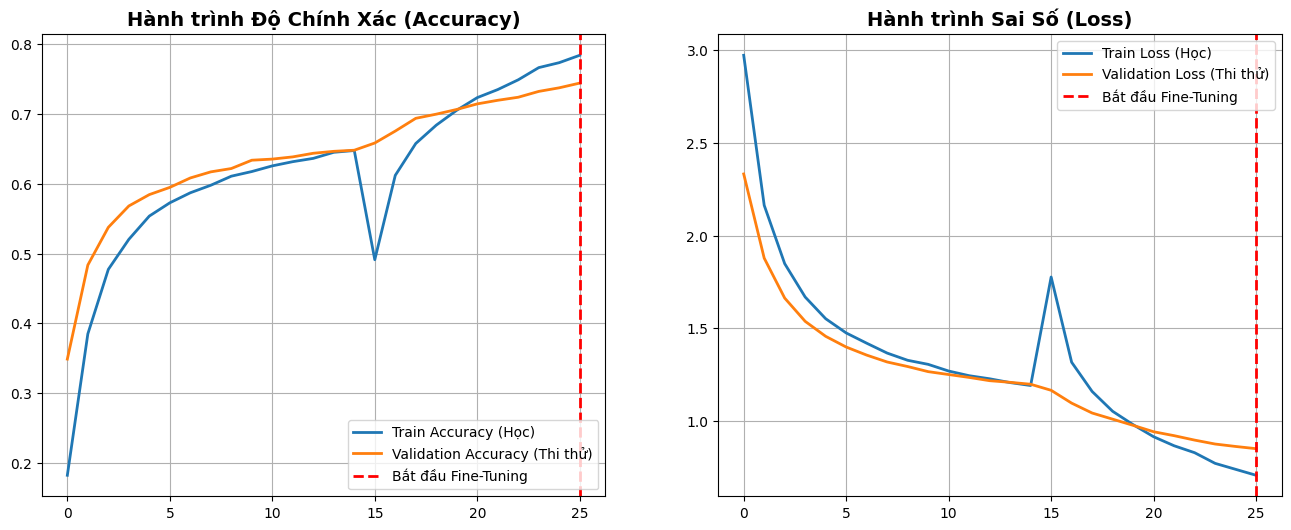


Đang quét tập Validation để lập Báo Cáo Chuyên Sâu...

BÁO CÁO CHẤT LƯỢNG MÔ HÌNH (SAU FINE-TUNING)
                  precision    recall  f1-score   support

        Banh beo       0.87      0.74      0.80        65
    Banh bot loc       0.61      0.64      0.63        73
        Banh can       0.89      0.77      0.83        75
       Banh canh       0.54      0.48      0.51        97
      Banh chung       0.77      0.66      0.71        50
       Banh cuon       0.72      0.81      0.76       114
        Banh duc       0.66      0.32      0.43        66
        Banh gio       0.79      0.83      0.81        64
       Banh khot       0.82      0.69      0.75        84
         Banh mi       0.92      0.92      0.92       133
        Banh pia       0.93      0.91      0.92        45
        Banh tet       0.72      0.82      0.77        68
Banh trang nuong       0.91      0.72      0.81        80
        Banh xeo       0.82      0.83      0.82       117
      Bun bo Hue       0.60 

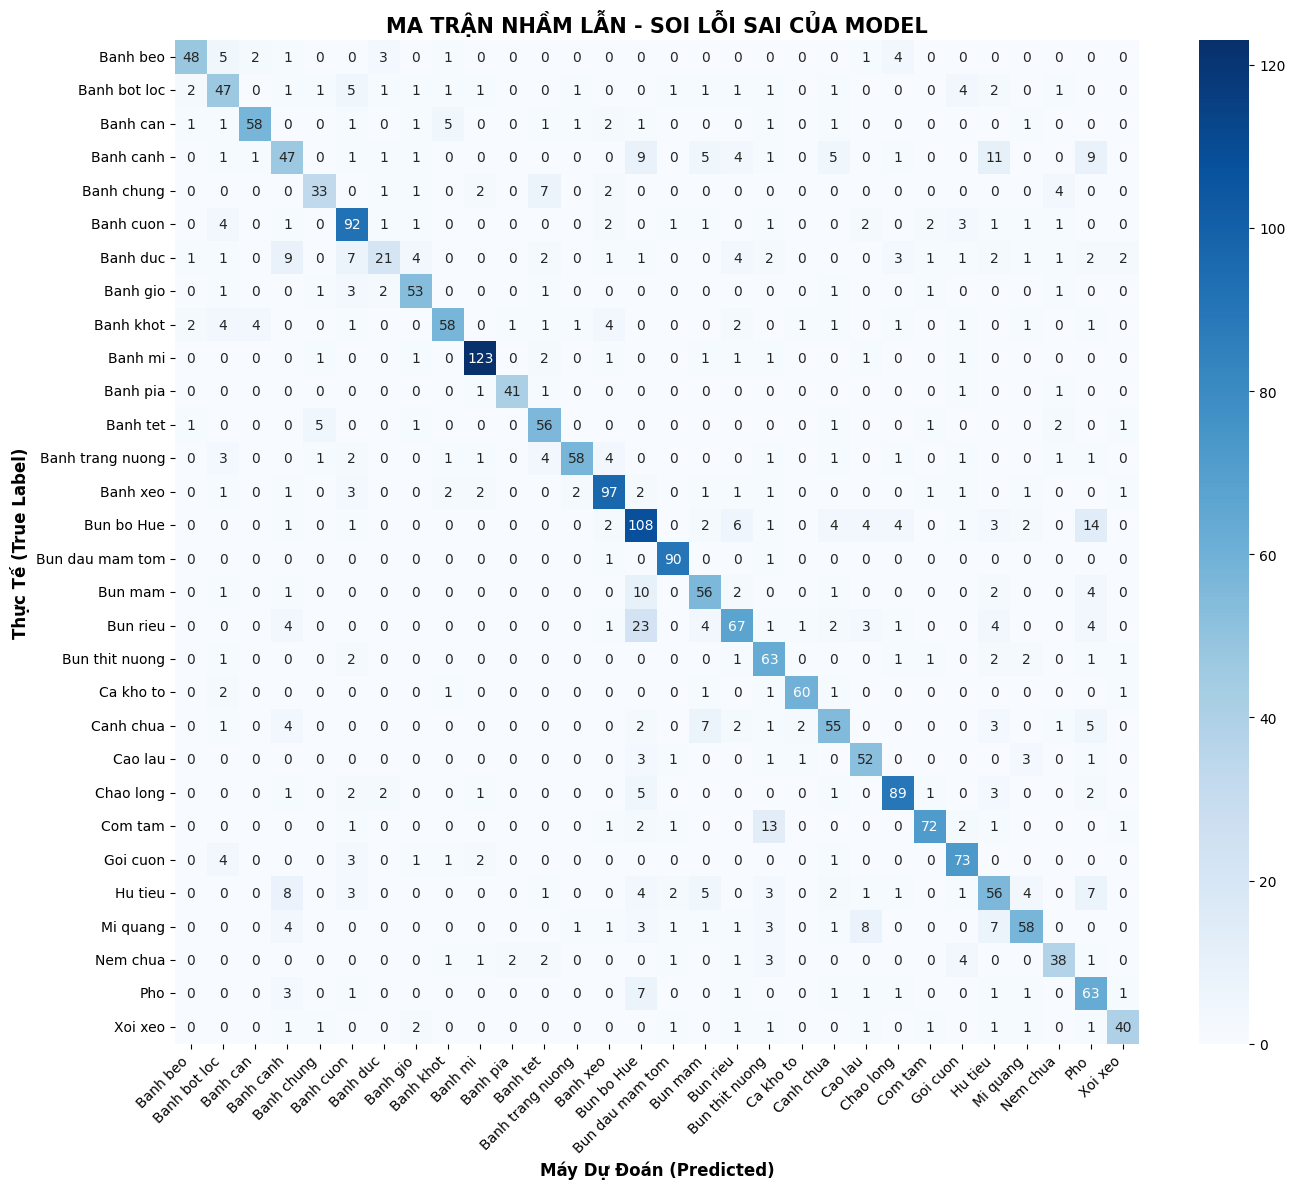

In [7]:
# --- BƯỚC 6: ĐÁNH GIÁ VÀ NGHIỆM THU MÔ HÌNH TOÀN DIỆN ---
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Đang vẽ biểu đồ Đánh giá quá trình học (Learning Curves)...")

# ==========================================================
# 1. VẼ BIỂU ĐỒ LEARNING CURVE (Nối 2 giai đoạn học)
# ==========================================================
# Rút dữ liệu từ Giai đoạn 1 (Warm-up)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Nối thêm dữ liệu từ Giai đoạn 2 (Fine-tuning)
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']
loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

plt.figure(figsize=(16, 6))

# ---- Biểu đồ Accuracy ----
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy (Học)', linewidth=2)
plt.plot(val_acc, label='Validation Accuracy (Thi thử)', linewidth=2)
# Kẻ đường ranh giới bắt đầu Fine-tune
plt.axvline(x=len(history.history['accuracy'])-1, label='Bắt đầu Fine-Tuning', linestyle='--', color='red', linewidth=2)
plt.legend(loc='lower right')
plt.title('Hành trình Độ Chính Xác (Accuracy)', fontsize=14, fontweight='bold')
plt.grid(True)

# ---- Biểu đồ Loss ----
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss (Học)', linewidth=2)
plt.plot(val_loss, label='Validation Loss (Thi thử)', linewidth=2)
plt.axvline(x=len(history.history['loss'])-1, label='Bắt đầu Fine-Tuning', linestyle='--', color='red', linewidth=2)
plt.legend(loc='upper right')
plt.title('Hành trình Sai Số (Loss)', fontsize=14, fontweight='bold')
plt.grid(True)

plt.show()

# ==========================================================
# 2. XUẤT CÁC CHỈ SỐ QUAN TRỌNG VÀ MA TRẬN NHẦM LẪN
# ==========================================================
print("\nĐang quét tập Validation để lập Báo Cáo Chuyên Sâu...")
y_true = []
y_pred = []

# Quét qua toàn bộ tập thi thử (Validation Dataset)
for images, labels in validation_dataset:
    y_true.extend(labels.numpy())
    
    # Dự đoán (Hàm softmax nhả ra mảng xác suất)
    preds = model.predict(images, verbose=0)
    
    # DÙNG ARGMAX: Chốt hạ nhãn có xác suất cao nhất để đánh giá cơ bản
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ---- In Báo Cáo Chữ (Precision, Recall, F1-Score) ----
print("\n" + "="*70)
print("BÁO CÁO CHẤT LƯỢNG MÔ HÌNH (SAU FINE-TUNING)")
print("="*70)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# ---- Vẽ Ma Trận Nhầm Lẫn (Confusion Matrix) ----
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Máy Dự Đoán (Predicted)', fontsize=12, fontweight='bold')
plt.ylabel('Thực Tế (True Label)', fontsize=12, fontweight='bold')
plt.title('MA TRẬN NHẦM LẪN - SOI LỖI SAI CỦA MODEL', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Đang tải tập Test để đánh giá Threshold...
Found 5040 files belonging to 30 classes.
Đang chạy mô hình để lấy mảng xác suất trên toàn bộ tập Test...
Đang tính toán các chỉ số cho từng mức Threshold...


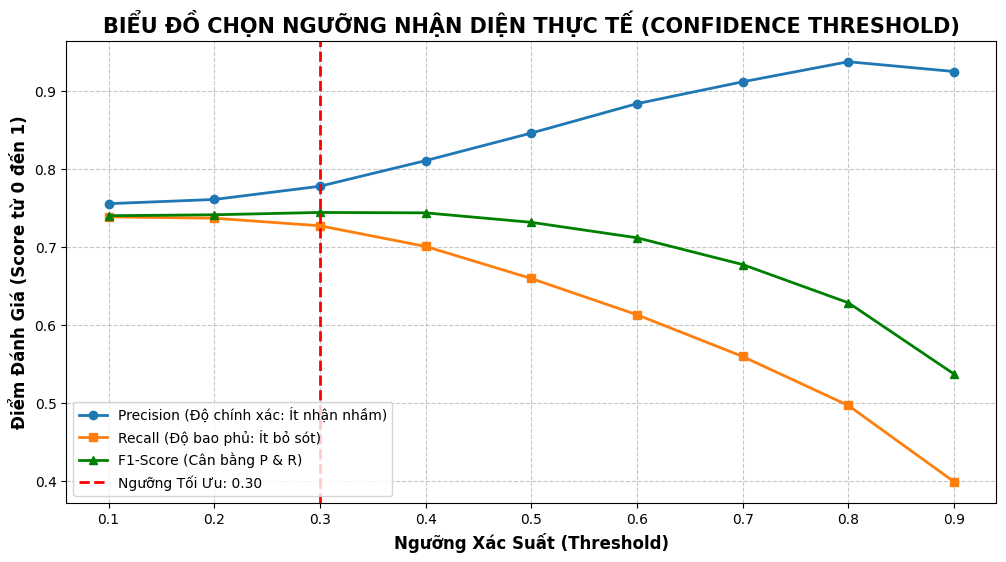


=> KẾT LUẬN CỦA HỆ THỐNG:
Ngưỡng an toàn và tối ưu nhất để đưa vào code Backend là: 0.30
Tại mức ngưỡng này, mô hình đạt được F1-Score cao nhất, giữ cân bằng xuất sắc giữa việc không nhận diện láo (Precision) và không bỏ lọt món ăn hợp lệ (Recall).


In [8]:
# --- BƯỚC 7: TÌM NGƯỠNG (THRESHOLD) TỐI ƯU TRÊN TẬP TEST ĐỘC LẬP ---
from sklearn.metrics import precision_score, recall_score, f1_score
import tensorflow as tf

print("Đang tải tập Test để đánh giá Threshold...")
# Đảm bảo đường dẫn này trỏ đúng vào thư mục Test của bạn nhé
test_dir = '/kaggle/working/Purified_Images/Test'

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224), 
    batch_size=32,
    shuffle=False # Bắt buộc False để đối chiếu nhãn không bị lệch
)

y_true_test = []
y_pred_probs = []

print("Đang chạy mô hình để lấy mảng xác suất trên toàn bộ tập Test...")
for images, labels in test_dataset:
    y_true_test.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true_test = np.array(y_true_test)
y_pred_probs = np.array(y_pred_probs)
valid_labels = np.unique(y_true_test) 

# Thử nghiệm các ngưỡng từ 0.1 đến 0.9 (Bước nhảy 0.1)
thresholds = np.arange(0.1, 1.0, 0.1)
precisions = []
recalls = []
f1_scores = []

print("Đang tính toán các chỉ số cho từng mức Threshold...")
for thresh in thresholds:
    y_pred_thresh = []
    
    for prob in y_pred_probs:
        # Nếu xác suất cao nhất >= ngưỡng -> Máy tự tin, lấy nhãn đó
        if np.max(prob) >= thresh:
            y_pred_thresh.append(np.argmax(prob))
        # Nếu < ngưỡng -> Máy không tự tin, đánh dấu là -1 (Unknown)
        else:
            y_pred_thresh.append(-1) 
            
    # Tính điểm: Macro trung bình, bỏ qua những nhãn -1
    p = precision_score(y_true_test, y_pred_thresh, labels=valid_labels, average='macro', zero_division=0)
    r = recall_score(y_true_test, y_pred_thresh, labels=valid_labels, average='macro', zero_division=0)
    f1 = f1_score(y_true_test, y_pred_thresh, labels=valid_labels, average='macro', zero_division=0)
    
    precisions.append(p)
    recalls.append(r)
    f1_scores.append(f1)

# ==========================================================
# VẼ BIỂU ĐỒ TRỰC QUAN ĐỂ TÌM NGƯỠNG
# ==========================================================
plt.figure(figsize=(12, 6))
plt.plot(thresholds, precisions, marker='o', label='Precision (Độ chính xác: Ít nhận nhầm)', linewidth=2)
plt.plot(thresholds, recalls, marker='s', label='Recall (Độ bao phủ: Ít bỏ sót)', linewidth=2)
plt.plot(thresholds, f1_scores, marker='^', label='F1-Score (Cân bằng P & R)', linewidth=2, color='green')

# Tìm Threshold cho F1-Score cao nhất
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

# Kẻ đường kẻ dọc đỏ chỉ điểm vàng
plt.axvline(x=best_threshold, color='red', linestyle='--', linewidth=2, label=f'Ngưỡng Tối Ưu: {best_threshold:.2f}')

plt.title('BIỂU ĐỒ CHỌN NGƯỠNG NHẬN DIỆN THỰC TẾ (CONFIDENCE THRESHOLD)', fontsize=15, fontweight='bold')
plt.xlabel('Ngưỡng Xác Suất (Threshold)', fontsize=12, fontweight='bold')
plt.ylabel('Điểm Đánh Giá (Score từ 0 đến 1)', fontsize=12, fontweight='bold')
plt.xticks(thresholds)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"\n=> KẾT LUẬN CỦA HỆ THỐNG:")
print(f"Ngưỡng an toàn và tối ưu nhất để đưa vào code Backend là: {best_threshold:.2f}")
print("Tại mức ngưỡng này, mô hình đạt được F1-Score cao nhất, giữ cân bằng xuất sắc giữa việc không nhận diện láo (Precision) và không bỏ lọt món ăn hợp lệ (Recall).")

In [10]:
# --- BƯỚC 8: LƯU TRỮ MÔ HÌNH ĐỂ MANG ĐI SỬ DỤNG (PRODUCTION) ---
# Lúc này biến 'model' đang mang bộ trọng số tốt nhất sau khi đã Fine-tuning.

# 1. Lưu dưới định dạng .h5 (Chuẩn cũ, tương thích tốt với nhiều thư viện Backend cũ)
model_path_h5 = 'vietnamese_food_mobilenetv2.h5'
model.save(model_path_h5)
print(f"=> Đã lưu model định dạng H5 tại: /kaggle/working/{model_path_h5}")

# 2. Lưu dưới định dạng .keras (Chuẩn mới nhất, an toàn và được TensorFlow khuyên dùng)
model_path_keras = 'vietnamese_food_mobilenetv2.keras'
model.save(model_path_keras)
print(f"=> Đã lưu model định dạng KERAS tại: /kaggle/working/{model_path_keras}")

print("\nHoàn tất 100%! Bây giờ bạn có thể tải cả 2 file này về máy để dành xài cho Frontend/Backend nhé!")

=> Đã lưu model định dạng H5 tại: /kaggle/working/vietnamese_food_mobilenetv2.h5
=> Đã lưu model định dạng KERAS tại: /kaggle/working/vietnamese_food_mobilenetv2.keras

Hoàn tất 100%! Bây giờ bạn có thể tải cả 2 file này về máy để dành xài cho Frontend/Backend nhé!
